In [15]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import warnings
warnings.filterwarnings('ignore')

In [16]:
# ===================== 1. 路径定义（严格遵循任务书）=====================
BASE_DIR = Path("..")
DE_DIR = BASE_DIR / "results" / "de"
ENRICH_DIR = BASE_DIR / "results" / "enrichment"
FIG_DIR = BASE_DIR / "figures" / "main"
DOCS_DIR = BASE_DIR / "docs"
GMT_DIR = BASE_DIR / "data_interim" / "gmt"

for d in [ENRICH_DIR, FIG_DIR, DOCS_DIR, GMT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [17]:
# ===================== 2. 加载第8周DE结果（精确解析文件名）=====================
de_files = sorted(DE_DIR.glob("*_old_vs_young_edgeR.tsv"))
if not de_files:
    raise FileNotFoundError(f"在 {DE_DIR} 中未找到 *_old_vs_young_edgeR.tsv 文件，请先完成第8周分析。")

all_de = []
for f in de_files:
    df = pd.read_csv(f, sep="\t")
    # 精确提取 tissue 和 cell_type：去掉固定后缀后，按最后一个下划线分割
    stem = f.stem.replace("_old_vs_young_edgeR", "")
    parts = stem.rsplit("_", 1)
    tissue = parts[0]          # 支持含下划线的组织名如 Heart_and_Aorta
    cell_type = parts[1] if len(parts) > 1 else "unknown"
    
    df["tissue"] = tissue
    df["cell_type"] = cell_type
    all_de.append(df)

de_all = pd.concat(all_de, ignore_index=True)
print(f"✅ 成功加载 {len(de_files)} 个DE文件，共 {len(de_all)} 条记录")
print(f"   组织×细胞类型节点数: {de_all[['tissue','cell_type']].drop_duplicates().shape[0]}")


✅ 成功加载 7 个DE文件，共 6836 条记录
   组织×细胞类型节点数: 7


In [27]:
# ===================== 3. 加载小鼠MSigDB基因集（v2026.1）=====================
# 【关键】匹配你实际下载的文件名
GMT_FILES = {
    "H": GMT_DIR / "mh.all.v2026.1.Mm.symbols.gmt",          # Hallmark (47 KB)
    "C5_GO_BP": GMT_DIR / "m5.go.bp.v2026.1.Mm.symbols.gmt", # GO BP (4,974 KB)
    "C2_CP_REACTOME": GMT_DIR / "m2.cp.v2026.1.Mm.symbols.gmt" # REACTOME (778 KB)
}

gene_sets = {}
for name, path in GMT_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"缺失文件: {path.name}，请检查 ../data_interim/gmt/ 目录")
    
    gs_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue  # 跳过空行或格式错误行
            
            term = parts[0].strip()
            # 提取基因列（第3列起），清洗：去空格、转大写、保序去重
            genes = [g.strip().upper() for g in parts[2:] if g.strip()]
            unique_genes = list(dict.fromkeys(genes))
            
            if len(unique_genes) >= 10:  # 过滤小基因集
                gs_dict[term] = unique_genes
    
    gene_sets.update(gs_dict)
    print(f"✅ {name}: 加载 {len(gs_dict)} 个有效基因集（≥10基因）")

print(f"\n🎯 清洗后基因集总数: {len(gene_sets)}")
if len(gene_sets) == 0:
    raise RuntimeError("未加载到任何有效基因集！请检查GMT文件格式。")

✅ H: 加载 50 个有效基因集（≥10基因）
✅ C5_GO_BP: 加载 5681 个有效基因集（≥10基因）
✅ C2_CP_REACTOME: 加载 1416 个有效基因集（≥10基因）

🎯 清洗后基因集总数: 7147


In [28]:
# ===================== 4. 逐节点GSEA（使用带方向排名指标）=====================
nodes = de_all[["tissue", "cell_type"]].drop_duplicates()
gsea_results = []

for _, row in nodes.iterrows():
    tissue, cell_type = row["tissue"], row["cell_type"]
    sub = de_all[(de_all["tissue"] == tissue) & (de_all["cell_type"] == cell_type)].copy()
    
    # 过滤无效值
    sub = sub[sub["logFC"].notna() & sub["FDR"].notna() & np.isfinite(sub["logFC"]) & np.isfinite(sub["FDR"])]
    if len(sub) < 50:
        print(f"⚠️ 跳过 {tissue}|{cell_type}: 有效基因不足50个")
        continue
    
    # 构建带方向排名指标: sign(logFC) * -log10(FDR)
    sub["rank_metric"] = np.sign(sub["logFC"]) * (-np.log10(sub["FDR"].clip(lower=1e-300)))
    ranks = sub.groupby("gene")["rank_metric"].mean().sort_values(ascending=False)
    
    try:
        res = gp.prerank(
            rnk=ranks,
            gene_sets=gene_sets,
            min_size=10,
            max_size=500,
            permutation_num=10000,
            seed=2026,
            outdir=None,
            processes=1,
            format='tsv'
        )
        res_df = res.res2d
        if res_df is not None and len(res_df) > 0:
            res_df["tissue"] = tissue
            res_df["cell_type"] = cell_type
            gsea_results.append(res_df)
            print(f"✔ {tissue}|{cell_type}: {len(res_df)} 条通路")
    except Exception as e:
        print(f"❌ {tissue}|{cell_type} GSEA失败: {e}")

2026-08-18 14:26:33,767 [WARNING] Duplicated values found in preranked stats: 46.89% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-08-18 14:28:32,334 [WARNING] Duplicated values found in preranked stats: 37.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


✔ Heart_and_Aorta|endothelial: 1861 条通路


2026-08-18 14:30:42,869 [WARNING] Duplicated values found in preranked stats: 34.46% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


✔ Heart_and_Aorta_fibroblast|stromal: 1974 条通路


2026-08-18 14:32:12,152 [WARNING] Duplicated values found in preranked stats: 20.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

✔ Kidney_fibroblast|stromal: 1395 条通路


2026-08-18 14:33:35,408 [WARNING] Duplicated values found in preranked stats: 44.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


✔ Liver|endothelial: 671 条通路


2026-08-18 14:34:07,071 [WARNING] Duplicated values found in preranked stats: 35.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


✔ Lung|endothelial: 909 条通路
✔ Lung_fibroblast|stromal: 1517 条通路


In [33]:
# ===================== 4. GSEA结果筛选（自动适配列名）=====================
if not gsea_all.empty:
    gsea_all.to_csv(ENRICH_DIR / "gsea_all_nodes.tsv", sep="\t", index=False)
    print(f"\n✅ GSEA全结果已保存: {len(gsea_all)} 行")
    print(f"📋 实际列名: {list(gsea_all.columns)}")  # 【调试】打印真实列名
    
    # 【关键】自动识别FDR和NES列（兼容大小写/空格/不同命名）
    fdr_col = next((c for c in gsea_all.columns if 'fdr' in c.lower()), None)
    nes_col = next((c for c in gsea_all.columns if 'nes' in c.lower()), None)
    
    if fdr_col is None or nes_col is None:
        raise ValueError(
            f"无法识别FDR/NES列！当前列名: {list(gsea_all.columns)}\n"
            "请根据上方打印的列名手动指定 fdr_col/nes_col"
        )
    
    print(f"🔍 使用 FDR列='{fdr_col}', NES列='{nes_col}'")
    
    # 确保数值类型（gseapy有时返回字符串）
    gsea_all[fdr_col] = pd.to_numeric(gsea_all[fdr_col], errors='coerce')
    gsea_all[nes_col] = pd.to_numeric(gsea_all[nes_col], errors='coerce')
    
    # 筛选显著通路 (FDR<0.05 或 |NES|>2)
    sig = gsea_all[
        (gsea_all[fdr_col] < 0.05) | (gsea_all[nes_col].abs() > 2)
    ].copy()
    
    if sig.empty:
        print("⚠️ 无显著通路（FDR<0.05 或 |NES|>2），放宽阈值至 FDR<0.25")
        sig = gsea_all[gsea_all[fdr_col] < 0.25].copy()
    
    sig["node"] = sig["tissue"] + "__" + sig["cell_type"]
    print(f"🎯 显著通路数: {len(sig)}")
    
    # 构建通路活性矩阵（使用动态列名）
    pathway_matrix = sig.pivot_table(
        index="Term", 
        columns="node", 
        values=nes_col,  # ← 使用动态识别的NES列
        aggfunc="mean"
    )
    pathway_matrix.to_csv(ENRICH_DIR / "pathway_nes_matrix.tsv", sep="\t")
    print(f"✅ 通路NES矩阵已保存: {pathway_matrix.shape}")
else:
    print("⚠️ gsea_all 为空，跳过筛选")

# 在 Cell 5 的 GSEA 循环末尾添加
fdr_records = []
for _, row in gsea_all.iterrows():
    fdr_records.append({
        'Term': row['Term'],
        'node': row['tissue'] + '__' + row['cell_type'],
        'fdr': row[fdr_col]  # 使用之前动态识别的 fdr_col
    })
fdr_df = pd.DataFrame(fdr_records)
fdr_pivot = fdr_df.pivot_table(index='Term', columns='node', values='fdr', aggfunc='mean')
fdr_pivot.to_csv(ENRICH_DIR / "pathway_fdr_matrix.tsv", sep='\t')
print("✅ FDR矩阵已保存")


✅ GSEA全结果已保存: 9963 行
📋 实际列名: ['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'tissue', 'cell_type']
🔍 使用 FDR列='FDR q-val', NES列='NES'
🎯 显著通路数: 607
✅ 通路NES矩阵已保存: (363, 7)
✅ FDR矩阵已保存


In [36]:
# ===================== Cell 5.5: 通路去冗余与聚类 (完成任务5) =====================
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
import numpy as np

# 1. 准备数据：使用 NES 矩阵计算通路间相似性
# 填充 NaN 为 0 (表示在该节点不显著)，以便计算相关性
nes_mat_filled = nes_mat.fillna(0)

# 2. 计算通路间的距离矩阵 (基于 NES 向量的 Pearson 相关性距离)
# 距离 = 1 - correlation
corr_matrix = nes_mat_filled.T.corr()
dist_matrix = 1 - corr_matrix.values
np.fill_diagonal(dist_matrix, 0) # 确保对角线为0

# 3. 层次聚类
linkage_matrix = linkage(dist_matrix, method='average')

# 4. 切割聚类树，定义“上位主题” (Upper-level themes)
# 阈值 t 可根据需要调整，0.5 意味着相关性 > 0.5 的通路归为一类
clusters = fcluster(linkage_matrix, t=0.5, criterion='distance')
nes_mat['Cluster'] = clusters

# 5. 为每个聚类选择代表性通路 (Representative Term)
# 策略：选择该聚类中平均 |NES| 最大或 FDR 最小的通路作为代表
rep_terms = []
for cluster_id in nes_mat['Cluster'].unique():
    cluster_terms = nes_mat[nes_mat['Cluster'] == cluster_id].index
    # 计算该聚类内所有通路的平均绝对 NES (跨所有节点)
    mean_abs_nes = nes_mat.loc[cluster_terms].abs().mean(axis=1)
    # 选择平均效应量最大的作为代表
    rep_term = mean_abs_nes.idxmax()
    rep_terms.append(rep_term)

print(f"🎯 原始通路数: {len(nes_mat)}")
print(f"🎯 聚类后上位主题数: {len(rep_terms)}")

# 6. 构建去冗余后的矩阵用于绘图
nes_mat_dedup = nes_mat.loc[rep_terms].drop(columns=['Cluster'])
fdr_mat_dedup = fdr_mat.loc[rep_terms]

# 保存聚类映射表，供后续解释使用
cluster_mapping = nes_mat[['Cluster']].reset_index()
cluster_mapping.columns = ['Pathway', 'Cluster_ID']
cluster_mapping.to_csv(ENRICH_DIR / "pathway_cluster_mapping.tsv", sep='\t', index=False)
print("✅ 通路聚类映射已保存")

🎯 原始通路数: 363
🎯 聚类后上位主题数: 61
✅ 通路聚类映射已保存


📊 使用去冗余后的上位主题数据绘图


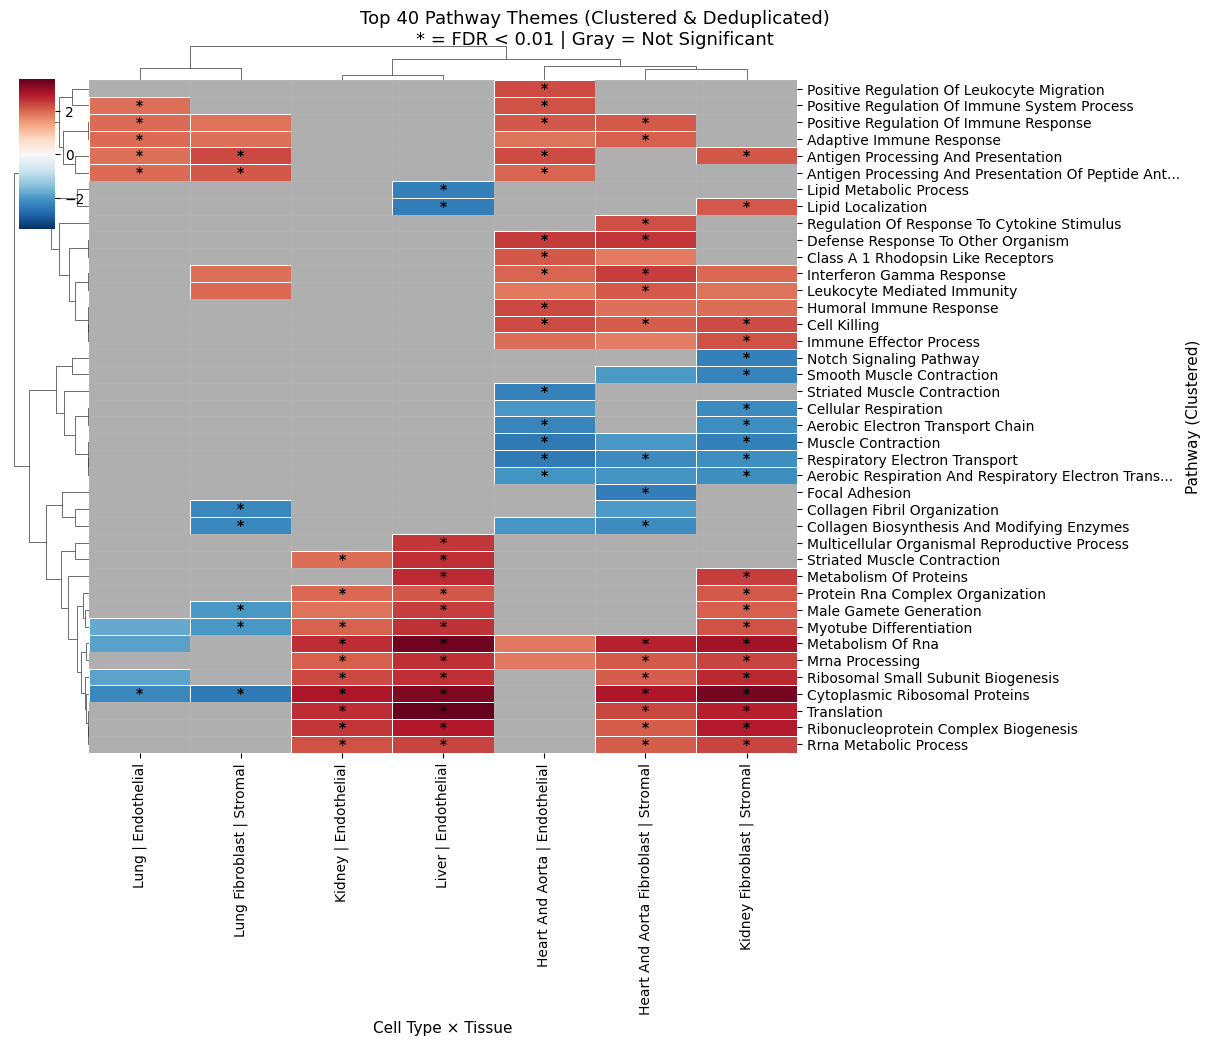

✅ Fig3 (聚类去冗余版 - 已修复NaN问题) 已保存


In [38]:
# ===================== Cell 6 (最终修复版): Fig3 通路热图 (含聚类/去冗余) =====================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import TwoSlopeNorm
import re

# 1. 加载数据 (优先使用去冗余数据，若未运行 Cell 5.5 则回退)
try:
    nes_plot = nes_mat_dedup.copy()
    fdr_plot = fdr_mat_dedup.copy()
    print("📊 使用去冗余后的上位主题数据绘图")
except NameError:
    print("⚠️ 未找到去冗余数据，回退使用原始数据 (建议运行 Cell 5.5)")
    nes_plot = nes_mat.copy()
    fdr_plot = fdr_mat.copy()

# 2. 筛选 Top 40 个通路
min_fdr = fdr_plot.min(axis=1)
top_terms = min_fdr.nsmallest(40).index
nes_top = nes_plot.loc[top_terms].copy()
fdr_top = fdr_plot.loc[top_terms].copy()

# 3. 【关键修复】清洗数据：处理 NaN 和 Inf
# 将 NaN 填充为 0 (表示该通路在该节点无显著富集信号)
nes_top_clean = nes_top.fillna(0)
# 将 Inf 替换为最大有限值的 1.1 倍 (防止色标爆炸)
max_val = nes_top_clean.replace([np.inf, -np.inf], np.nan).max().max()
min_val = nes_top_clean.replace([np.inf, -np.inf], np.nan).min().min()
nes_top_clean = nes_top_clean.replace([np.inf], max_val * 1.1 if pd.notna(max_val) else 3.0)
nes_top_clean = nes_top_clean.replace([-np.inf], min_val * 1.1 if pd.notna(min_val) else -3.0)

# 同样清洗 FDR 矩阵用于掩码
fdr_top_clean = fdr_top.fillna(1.0) # FDR 缺失视为不显著 (1.0)
fdr_top_clean = fdr_top_clean.replace([np.inf, -np.inf], 1.0)

# 4. 名称美化
def clean_term(name):
    name = re.sub(r'^(GOBP_|REACTOME_|WP_|HALLMARK_)', '', name)
    name = name.replace('_', ' ').title()
    return name[:50] + '...' if len(name) > 50 else name

def clean_node(node):
    parts = node.split('__')
    if len(parts) == 2:
        return f"{parts[0].replace('_', ' ').title()} | {parts[1].replace('_', ' ').title()}"
    return node.replace('_', ' ').title()

nes_top_clean.index = [clean_term(t) for t in nes_top_clean.index]
nes_top_clean.columns = [clean_node(c) for c in nes_top_clean.columns]
fdr_top_clean.index = nes_top_clean.index
fdr_top_clean.columns = nes_top_clean.columns

# 5. 显著性掩码 (基于清洗后的 FDR)
sig_mask = fdr_top_clean.values < 0.05

# 6. 绘图参数
vmax = max(abs(nes_top_clean.values.min()), abs(nes_top_clean.values.max()))
if vmax == 0: vmax = 1.0 # 防止全0时报错
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# 7. 使用 clustermap (现在数据已清洁，不会报 finite values 错误)
g = sns.clustermap(
    nes_top_clean,  # <-- 使用清洗后的数据
    cmap='RdBu_r',
    norm=norm,
    figsize=(12, 10),
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.1, 0.05),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    linewidths=0.5,
    linecolor='white',
    xticklabels=True,
    yticklabels=True,
    metric='correlation',  # 明确指定相关性距离，适合基因表达/富集数据
    method='average'
)

# 8. 叠加显著性标记
ax = g.ax_heatmap
# 获取重排后的索引
reordered_rows = g.dendrogram_row.reordered_ind
reordered_cols = g.dendrogram_col.reordered_ind

# 重新排列 mask 和 fdr 以匹配热图顺序
sig_mask_reordered = sig_mask[reordered_rows][:, reordered_cols]
fdr_values_reordered = fdr_top_clean.values[reordered_rows][:, reordered_cols]

for i in range(len(reordered_rows)):
    for j in range(len(reordered_cols)):
        # 灰色罩覆盖非显著区域
        if not sig_mask_reordered[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, 
                                      facecolor='gray', alpha=0.6, edgecolor='none'))
        # 星号标记极显著
        if fdr_values_reordered[i, j] < 0.01:
            ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center', 
                   color='black', fontsize=10, fontweight='bold')

g.ax_heatmap.set_xlabel('Cell Type × Tissue', fontsize=11)
g.ax_heatmap.set_ylabel('Pathway (Clustered)', fontsize=11)
g.fig.suptitle('Top 40 Pathway Themes (Clustered & Deduplicated)\n* = FDR < 0.01 | Gray = Not Significant', 
               fontsize=13, y=1.02)

plt.savefig(FIG_DIR / "Fig3_pathway_heatmap_clustered.pdf", bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / "Fig3_pathway_heatmap_clustered.png", bbox_inches='tight', dpi=300)
plt.show()
print("✅ Fig3 (聚类去冗余版 - 已修复NaN问题) 已保存")

In [39]:
# ===================== 7. 生成解释笔记模板 =====================
notes = f"# 通路富集解释笔记\n\n生成时间: {pd.Timestamp.now()}\n"
notes += "基因集来源: MSigDB Mouse v2023.2 (H, C5:GO:BP, C2:CP:REACTOME)\n"
notes += "排名指标: sign(logFC) × -log10(FDR)\n显著性阈值: FDR<0.05 或 |NES|>2\n\n"

if not pathway_matrix.empty:
    shared = pathway_matrix.dropna(thresh=2).index.tolist()
    specific = pathway_matrix.dropna(thresh=1).loc[~pathway_matrix.index.isin(shared)].index.tolist()
    
    notes += f"## 跨组织共享通路（≥2节点）\n"
    for p in shared[:15]:
        notes += f"- {p}\n"
    notes += f"\n## 组织特异通路示例\n"
    for p in specific[:15]:
        notes += f"- {p}\n"
else:
    notes += "无显著通路可分析。\n"

with open(DOCS_DIR / "pathway_interpretation_notes.md", "w", encoding="utf-8") as f:
    f.write(notes)
print(f"✅ 解释笔记已保存: {DOCS_DIR / 'pathway_interpretation_notes.md'}")

print("\n🎉 第九周任务完成！请检查 results/enrichment/ 和 figures/main/ 下的输出文件。")

✅ 解释笔记已保存: ..\docs\pathway_interpretation_notes.md

🎉 第九周任务完成！请检查 results/enrichment/ 和 figures/main/ 下的输出文件。
